# Laboratory #6 : Face detection and recognition

At the end of this laboratory, you would get familiarized with

*   Face detection
    *   Integral images
    *   Haar-like feature computation
    *   Adaboost 
*   Face recognition
    *   Eigen Faces
    *   PCA and LDA
---

# Face Detection using AdaBoost

In [26]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from skimage import data, io
import os
import matplotlib
from PIL import Image
from multiprocessing import Pool
from functools import partial
import time
import timeit
from matplotlib import pyplot as plt

### Exercise #1

*   Build a function compute_integral_image that computes the integral image of an input (2D) array. In an integral image each pixel is the sum of all pixels in the original image that are 'left and above' the pixel. See the following example:

```
Original    Integral
+--------   +------------
| 1 2 3 .   | 0  0  0  0 .
| 4 5 6 .   | 0  1  3  6 .
| . . . .   | 0  5 12 21 .
            | . . . . . .
```

*   The integral image must have an additional row and column full of zeros (first row and first column).
*   Plot the output of the integral image for the following array:

```
img_array = np.array([[1,2,2,2,1],[1,2,2,2,1],[1,2,2,2,1],[1,2,2,2,1]])
```

In [27]:
def compute_integral_image(img_arr):
    """
    Calculates the integral image based on the original image data.
    :param img_arr: Image source data
    :type img_arr: numpy.ndarray
    :return Integral image for given image
    :rtype: numpy.ndarray
    """
    # an index of -1 refers to the last row/column
    # since row_sum is calculated starting from (0,0),
    # rowSum(x, -1) == 0 holds for all x
    row_sum = np.zeros(img_arr.shape)
    # we need an additional column and row
    integral_image_arr = np.zeros((img_arr.shape[0] + 1, img_arr.shape[1] + 1))

    # --------------------------------------------------------------------------
    # solution
    #
    # first row and column as zeros
    integral_image_arr[1:, 1:] = np.cumsum(img_arr, axis=0)
    integral_image_arr = np.cumsum(integral_image_arr, axis=1)
    # --------------------------------------------------------------------------


    return integral_image_arr

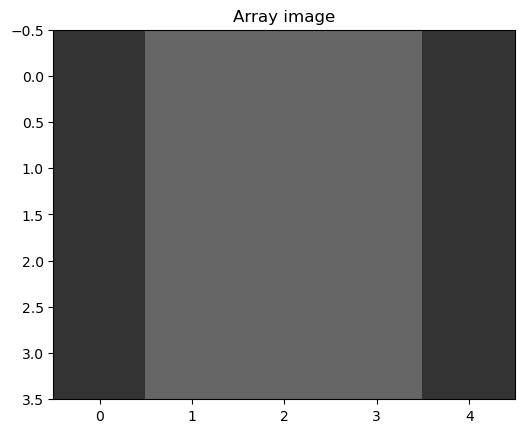

In [28]:
img_array = np.array([[1, 2, 2, 2, 1], [1, 2, 2, 2, 1], [1, 2, 2, 2, 1], [1, 2, 2, 2, 1]])
plt.imshow(img_array, cmap="gray", vmin=0, vmax= 5)
plt.title("Array image")
plt.show()

In [29]:
ii_img_array = compute_integral_image(img_array)
print(ii_img_array)

[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  1.  3.  5.  7.  8.]
 [ 0.  2.  6. 10. 14. 16.]
 [ 0.  3.  9. 15. 21. 24.]
 [ 0.  4. 12. 20. 28. 32.]]


*   Test the function using 'camera' image from the data module. Plot the original image and the integral image.

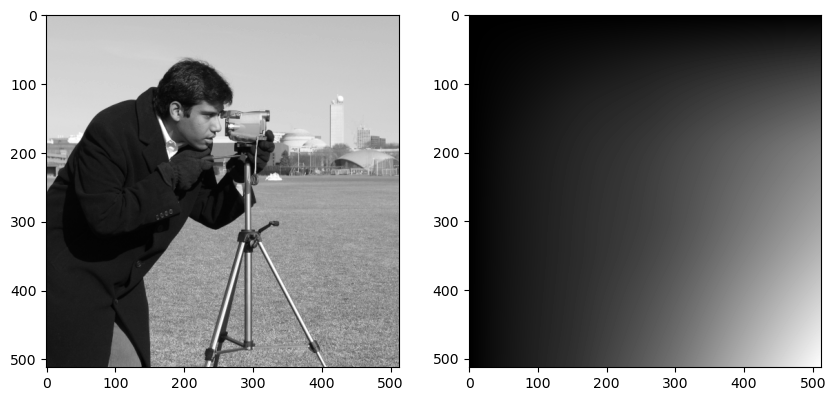

In [30]:
# solution

camera = data.camera()

camera_img_array = compute_integral_image(camera)
    
f, axarr = plt.subplots(ncols=2, nrows=1,figsize=(10,10))
axarr[0].imshow(camera, cmap='gray')
axarr[1].imshow(camera_img_array, cmap='gray', vmin=np.amin(camera_img_array), vmax= np.amax(camera_img_array))
plt.show()

### Exercise #2

*   Create a function sum_region to compute the sum of the pixel intensities within a rectangle using the integral image. The rectangle will be defined using the top left (x, y) and bottom right (x, y) coordinates.

In [31]:
def sum_region(integral_img_arr, top_left, bottom_right):

    # --------------------------------------------------------------------------
    # solution
    #
    A = integral_img_arr[top_left[0], top_left[1]] #Top left position
    B = integral_img_arr[top_left[0], bottom_right[1]] #Bottom left position
    C = integral_img_arr[bottom_right[0], top_left[1]] #Top right position
    D = integral_img_arr[bottom_right[0], bottom_right[1]] #Bottom right position

    # print(A, B, C, D)
    
    return D - C - B + A #Computing the sum of the pixel intensities
    # --------------------------------------------------------------------------

*   Make the following tests:

In [32]:
# result you should get (12)
print(sum_region(ii_img_array, [1, 1], [3, 4]))

12.0


In [33]:
# result you should get (32)
print(sum_region(ii_img_array, [0, 0], [-1, -1]))

32.0


### Exercise #3

*   Build a function load_integral_images to read all the images inside a given folder and compute the integral image of every image

In [34]:
def load_integral_images(path):
    ii_images = []
    for idx, _file in enumerate(os.listdir(path)[1:6]):
        #### Complete here:
        #### Read image
        #### Remember to scale the images (with the max pixel intensity value)
        
        # --------------------------------------------------------------------------
        # solution
        #
        if ".png" in _file:
            image = io.imread(path+ '/' + _file)
            image = image/image.max()
            
            integral_image = compute_integral_image(image)
            integral_image = integral_image/integral_image.max() 
            
            ii_images.append(integral_image)

            if idx % 100 == 0:
                print("Computing image number:",idx)

        # --------------------------------------------------------------------------
    return ii_images


# With this function we are reading each file in the folder, calculating its integral image and after that normalizing the image.
# Finally we put our processed image in the list that we will return

In [35]:
# change paths to your location

root_dir = 'images'

pos_training_path = os.path.join(root_dir, 'train_data/faces')
neg_training_path = os.path.join(root_dir, 'train_data/non_faces')
pos_testing_path = os.path.join(root_dir, 'test_data/faces')
neg_testing_path = os.path.join(root_dir, 'test_data/non_faces')

In [36]:
# solution

print('Loading all the list images')
t0 = time.time()

ii_faces_training = load_integral_images(pos_training_path)
ii_non_faces_training = load_integral_images(neg_training_path)
ii_faces_testing = load_integral_images(pos_testing_path)
ii_non_faces_testing = load_integral_images(neg_testing_path)

print(len(ii_faces_training))
print(len(ii_faces_testing))
print(len(ii_non_faces_training))
print(len(ii_non_faces_testing))

print("Done!")
print('Time needed:', time.time()-t0)

Loading all the list images
Computing image number: 0
Computing image number: 0
Computing image number: 0
Computing image number: 0
5
5
5
5
Done!
Time needed: 0.09150338172912598


*   Visualize a few original images and the corresponding integral images using matplotlib.

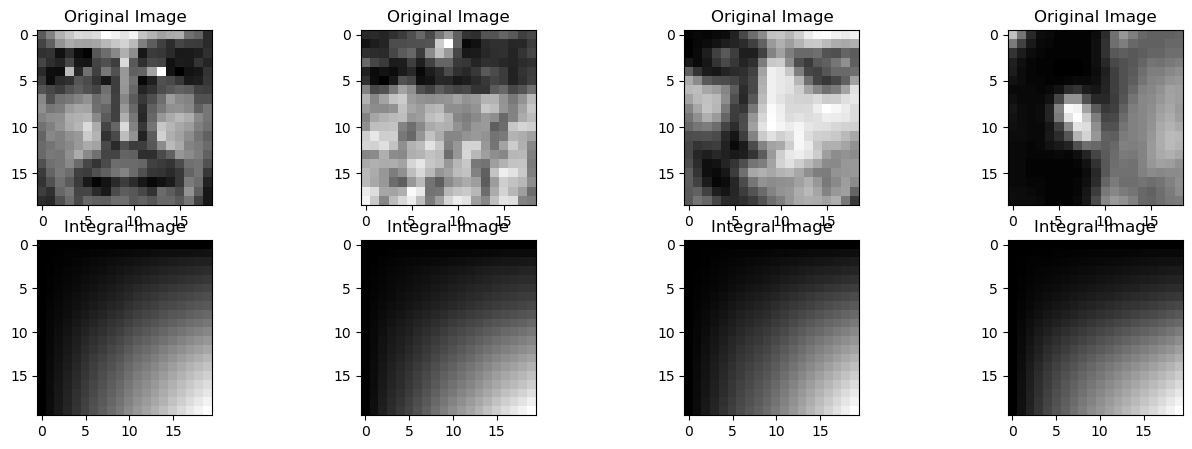

In [37]:
# solution

n = 4

images = [
          os.path.join(pos_training_path, os.listdir(pos_training_path)[1]),
          os.path.join(neg_training_path, os.listdir(neg_training_path)[1]),
          os.path.join(pos_testing_path, os.listdir(pos_testing_path)[1]), 
          os.path.join(neg_testing_path, os.listdir(neg_testing_path)[1])
          ]

integral_images = [
                   ii_faces_training[1],
                   ii_non_faces_training[1],
                   ii_faces_testing[1],
                   ii_non_faces_testing[1]
                   ]

f, axarr = plt.subplots(ncols=n, nrows=2,figsize=(16, 5))
for i in range(n):
    axarr[0][i].imshow(io.imread(images[i]), cmap='gray')
    axarr[0][i].set_title('Original Image')
    axarr[1][i].imshow(integral_images[i], cmap='gray')
    axarr[1][i].set_title('Integral Image')
plt.show()

### Exercise #4

*   Compute the Haar features of an image.
*   We provide you with HaarLikeFeature class that has build in a get_score function and a get_vote function. Your job is to complete the code of the method _create_features in the class HaarLikeFeature:

In [38]:
def enum(**enums):
    return type('Enum', (), enums)

FeatureType = enum(TWO_VERTICAL=(1, 2), TWO_HORIZONTAL=(2, 1), THREE_HORIZONTAL=(3, 1), THREE_VERTICAL=(1, 3), FOUR=(2, 2))
FeatureTypes = [FeatureType.TWO_VERTICAL, FeatureType.TWO_HORIZONTAL, FeatureType.THREE_VERTICAL, FeatureType.THREE_HORIZONTAL, FeatureType.FOUR]

In [39]:
class HaarLikeFeature(object):
    """
    Class representing a haar-like feature.
    """

    def __init__(self, feature_type, position, width, height, threshold, polarity):
        """
        Creates a new haar-like feature.
        :param feature_type: Type of new feature, see FeatureType enum
        :type feature_type: HaarLikeFeature.FeatureTypes
        :param position: Top left corner where the feature begins (x, y)
        :type position: (int, int)
        :param width: Width of the feature
        :type width: int
        :param height: Height of the feature
        :type height: int
        :param threshold: Feature threshold
        :type threshold: float
        :param polarity: polarity of the feature -1 or 1
        :type polarity: int
        """
        self.type = feature_type
        self.top_left = position
        self.bottom_right = (position[0] + width, position[1] + height)
        self.width = width
        self.height = height
        self.threshold = threshold
        self.polarity = polarity
        self.weight = 1
    
    def get_score(self, int_img):
        """
        Get score for given integral image array.
        :param int_img: Integral image array
        :type int_img: numpy.ndarray
        
        :return: Score for given feature
        :rtype: float
        """
        score = 0
        if self.type == FeatureType.TWO_VERTICAL:
            first = sum_region(int_img, self.top_left, (self.top_left[0] + self.width, int(self.top_left[1] + self.height / 2)))
            second = sum_region(int_img, (self.top_left[0], int(self.top_left[1] + self.height / 2)), self.bottom_right)
            score = first - second
        elif self.type == FeatureType.TWO_HORIZONTAL:
            first = sum_region(int_img, self.top_left, (int(self.top_left[0] + self.width / 2), self.top_left[1] + self.height))
            second = sum_region(int_img, (int(self.top_left[0] + self.width / 2), self.top_left[1]), self.bottom_right)
            score = first - second
        elif self.type == FeatureType.THREE_HORIZONTAL:
            first = sum_region(int_img, self.top_left, (int(self.top_left[0] + self.width / 3), self.top_left[1] + self.height))
            second = sum_region(int_img, (int(self.top_left[0] + self.width / 3), self.top_left[1]), (int(self.top_left[0] + 2 * self.width / 3), self.top_left[1] + self.height))
            third = sum_region(int_img, (int(self.top_left[0] + 2 * self.width / 3), self.top_left[1]), self.bottom_right)
            score = first - second + third
        elif self.type == FeatureType.THREE_VERTICAL:
            first = sum_region(int_img, self.top_left, (self.bottom_right[0], int(self.top_left[1] + self.height / 3)))
            second = sum_region(int_img, (self.top_left[0], int(self.top_left[1] + self.height / 3)), (self.bottom_right[0], int(self.top_left[1] + 2 * self.height / 3)))
            third = sum_region(int_img, (self.top_left[0], int(self.top_left[1] + 2 * self.height / 3)), self.bottom_right)
            score = first - second + third
        elif self.type == FeatureType.FOUR:
            # top left area
            first = sum_region(int_img, self.top_left, (int(self.top_left[0] + self.width / 2), int(self.top_left[1] + self.height / 2)))
            # top right area
            second = sum_region(int_img, (int(self.top_left[0] + self.width / 2), self.top_left[1]), (self.bottom_right[0], int(self.top_left[1] + self.height / 2)))
            # bottom left area
            third = sum_region(int_img, (self.top_left[0], int(self.top_left[1] + self.height / 2)), (int(self.top_left[0] + self.width / 2), self.bottom_right[1]))
            # bottom right area
            fourth = sum_region(int_img, (int(self.top_left[0] + self.width / 2), int(self.top_left[1] + self.height / 2)), self.bottom_right)
            score = first - second - third + fourth
        return score
    
    def get_vote(self, int_img):
        """
        Get vote of this feature for given integral image.
        :param int_img: Integral image array
        :type int_img: numpy.ndarray
        
        :return: 1 iff this feature votes positively, otherwise -1
        :rtype: int
        """
        score = self.get_score(int_img)
        return self.weight * (1 if score < self.polarity * self.threshold else -1)

In [40]:
def learn(positive_iis, negative_iis, num_classifiers=-1, min_feature_width=1, max_feature_width=-1, min_feature_height=1, max_feature_height=-1):
    """
    Selects a set of classifiers. Iteratively takes the best classifiers based
    on a weighted error.
    :param positive_iis: List of positive integral image examples
    :type positive_iis: list[numpy.ndarray]
    :param negative_iis: List of negative integral image examples
    :type negative_iis: list[numpy.ndarray]
    :param num_classifiers: Number of classifiers to select, -1 will use all
    classifiers
    :type num_classifiers: int
    
    :return: List of selected features
    :rtype: list[HaarLikeFeature.HaarLikeFeature]
    """
    num_pos = len(positive_iis)
    num_neg = len(negative_iis)
    num_imgs = num_pos + num_neg
    img_height, img_width = positive_iis[0].shape

    # Maximum feature width and height default to image width and height
    max_feature_height = img_height if max_feature_height == -1 else max_feature_height
    max_feature_width = img_width if max_feature_width == -1 else max_feature_width

    # Create initial weights and labels
    pos_weights = np.ones(num_pos) * 1. / (2 * num_pos)
    neg_weights = np.ones(num_neg) * 1. / (2 * num_neg)
    weights = np.hstack((pos_weights, neg_weights))
    labels = np.hstack((np.ones(num_pos), np.ones(num_neg) * -1)) 

    images = positive_iis + negative_iis

    # Create features for all sizes and locations
    features = _create_features(img_height, img_width, min_feature_width, max_feature_width, min_feature_height, max_feature_height)
    num_features = len(features)
    feature_indexes = list(range(num_features))

    num_classifiers = num_features if num_classifiers == -1 else num_classifiers

    print('Calculating scores for images..')
    t0 = time.time()
    votes = np.zeros((num_imgs, num_features))
    # Use as many workers as there are CPUs
    # pool = Pool(processes=1)
    # for i in range(num_imgs):
    #     votes[i, :] = np.array(list(pool.map(partial(_get_feature_vote, image=images[i]), features)))
    for i in range(num_imgs):
        votes[i, :] = np.array([feature.get_vote(images[i]) for feature in features])
    
    print('\tTime needed for calculating scores:', time.time()-t0)
    
    # select classifiers
    classifiers = []

    t0 = time.time()
    print('Selecting classifiers..')
    for _ in range(num_classifiers):

        classification_errors = np.zeros(len(feature_indexes))

        # normalize weights
        weights *= 1. / np.sum(weights)

        # select best classifier based on the weighted error
        for f in range(len(feature_indexes)):
            f_idx = feature_indexes[f]
            # classifier error is the sum of image weights where the classifier
            # is right
            error = sum(map(lambda img_idx: weights[img_idx] if labels[img_idx] != votes[img_idx, f_idx] else 0, range(num_imgs)))
            classification_errors[f] = error

        # get best feature, i.e. with smallest error
        min_error_idx = np.argmin(classification_errors)
        best_error = classification_errors[min_error_idx]
        best_feature_idx = feature_indexes[min_error_idx]

        # set feature weight
        best_feature = features[best_feature_idx]
        feature_weight = 0.5 * np.log((1 - best_error) / best_error)
        best_feature.weight = feature_weight

        classifiers.append(best_feature)

        # update image weights
        weights = np.array(list(map(lambda img_idx: weights[img_idx] * np.sqrt((1-best_error)/best_error) if labels[img_idx] != votes[img_idx, best_feature_idx] else weights[img_idx] * np.sqrt(best_error/(1-best_error)), range(num_imgs))))

        # remove feature (a feature can't be selected twice)
        feature_indexes.remove(best_feature_idx)

    print('\tTime needed for Selecting Classifiers:', time.time()-t0,'\n')

    return classifiers


def _create_features(img_height, img_width, min_feature_width, max_feature_width, min_feature_height, max_feature_height):
    print('Creating Haar-like features..')
    t0 = time.time()
    features = []
    for feature in FeatureTypes:
        # FeatureTypes are just tuples
        feature_start_width = max(min_feature_width, feature[0])
        for feature_width in range(feature_start_width, max_feature_width, feature[0]):
            feature_start_height = max(min_feature_height, feature[1])
            for feature_height in range(feature_start_height, max_feature_height, feature[1]):
                for x in range(img_height - max_feature_height):
                  for y in range(img_width - max_feature_width):
                    features.append(HaarLikeFeature(feature, (x, y), feature_width, feature_height, 0, 1))
                    features.append(HaarLikeFeature(feature, (x, y), feature_width, feature_height, 0, -1))
            
    print('\t' + str(len(features)) + ' features created.')
    print('\tTime needed for calculating Haar-like features:', time.time()-t0)
    return features

### Exercise #5

*   Use the learn method to learn a list of two classifiers with the train data. With the learn function you can build a list of classifiers that detect whether an image contains a face or not.

*   Use the following hyperparameters of the features and num_classifiers

In [41]:
num_classifiers = 2
min_feature_height = 8
max_feature_height = 10
min_feature_width = 8
max_feature_width = 10

In [42]:
%%time 
#classifiers = learn(...)

CPU times: total: 0 ns
Wall time: 0 ns


In [43]:
# solution

# %%time 
classifiers = learn(ii_faces_training, ii_non_faces_training, num_classifiers, min_feature_width, max_feature_width, min_feature_height, max_feature_height)

Creating Haar-like features..
	1800 features created.
	Time needed for calculating Haar-like features: 0.0010013580322265625
Calculating scores for images..
	Time needed for calculating scores: 0.0682528018951416
Selecting classifiers..
	Time needed for Selecting Classifiers: 0.018090009689331055 



### Exercise #6

*   Make a function for voting with different classifiers
*   Build two functions ensemble_vote and ensemble_vote_all.
*   **ensemble_vote(int_img, classifiers)** has to return a 1 if the majority of the votes of the classifiers is positive and a zero otherwise
*   **ensemble_vote_all(int_imgs, classifiers)** has to loop over the list int_imgs and compute the ensemble_vote for each image in the list. It has to return a list containing all the votes for all the images in int_imgs.


In [44]:
# solution

def ensemble_vote(int_img, classifiers):
    votes = []
    for classifier in classifiers:
        votes.append(classifier.get_vote(int_img))

    return 1 if sum(votes) > 0 else 0

In [45]:
def ensemble_vote_all(int_imgs, classifiers):
    votes = []
    for int_img in int_imgs:
        votes.append(ensemble_vote(int_img, classifiers))

    return votes

*   Use the functions to compute the train and test acurracies for faces and non faces.
*   Print the results in the following format:

```
train results:
Correctly identified Faces: 2129/2429  (87.64923836969946%)
Correctly identified non-Faces: 4276/8548  (50.02339728591484%)

test results:
Correctly identified Faces: 300/472  (63.559322033898304%)
Correctly identified non-Faces: 74/128  (57.8125%)
```

*   It is not required to get this exact results but print the information in this format. It facilitates understanding the results.

In [46]:
# solution

n_imgs = len(ii_faces_training)
result_vote_all = ensemble_vote_all(ii_faces_training, classifiers)
Correctly_identified = sum(result_vote_all)
percent_correct_identified = Correctly_identified / n_imgs * 100 
print("train results:")
print("Correctly identified Faces: ", Correctly_identified ,"/", n_imgs, " (", percent_correct_identified, "%)")


n_imgs = len(ii_non_faces_training)
result_vote_all = ensemble_vote_all(ii_non_faces_training, classifiers)
Correctly_identified = n_imgs-sum(result_vote_all) 
percent_correct_identified = Correctly_identified / n_imgs * 100 
print("Correctly identified non-Faces: ", Correctly_identified ,"/", n_imgs, " (", percent_correct_identified, "%)")

n_imgs = len(ii_faces_testing)
result_vote_all = ensemble_vote_all(ii_faces_testing, classifiers)
Correctly_identified = sum(result_vote_all)
percent_correct_identified = Correctly_identified / n_imgs * 100 
print("test results:")
print("Correctly identified Faces: ", Correctly_identified ,"/", n_imgs, " (", percent_correct_identified, "%)")

n_imgs = len(ii_non_faces_testing)
result_vote_all = ensemble_vote_all(ii_non_faces_testing, classifiers)
Correctly_identified = n_imgs-sum(result_vote_all)
percent_correct_identified = Correctly_identified / n_imgs * 100 
print("Correctly identified non-Faces: ", Correctly_identified ,"/", n_imgs, " (", percent_correct_identified, "%)")

train results:
Correctly identified Faces:  5 / 5  ( 100.0 %)
Correctly identified non-Faces:  4 / 5  ( 80.0 %)
test results:
Correctly identified Faces:  1 / 5  ( 20.0 %)
Correctly identified non-Faces:  3 / 5  ( 60.0 %)


### Exercise #7

*   Make another test with 20 classifiers instead of 2.
*   Inspect the classification results if you use adaboost with 20 classifiers. *   Use the same hyperameters for the features. Print the results as in the previous exercise.

In [47]:
num_classifiers = 20
min_feature_height = 8
max_feature_height = 10
min_feature_width = 8
max_feature_width = 10

In [48]:
%%time 
#classifiers_20 = learn(...)

CPU times: total: 0 ns
Wall time: 0 ns


In [49]:
classifiers_20 = learn(ii_faces_training, ii_non_faces_training, num_classifiers, min_feature_width, max_feature_width, min_feature_height, max_feature_height)

Creating Haar-like features..
	1800 features created.
	Time needed for calculating Haar-like features: 0.0013327598571777344
Calculating scores for images..


	Time needed for calculating scores: 0.06837105751037598
Selecting classifiers..
	Time needed for Selecting Classifiers: 0.1822962760925293 



*   Discuss if the classification results improved in the train data.


**Solution:**

**Analysis of Training Results with 20 Classifiers:**

Increasing the number of classifiers from 2 to 20 in AdaBoost significantly improves the classification results on the training data:

1. **Training Performance**: With 20 classifiers, the training accuracy improves substantially for both faces and non-faces compared to using only 2 classifiers. This is expected because AdaBoost iteratively focuses on difficult samples, and more classifiers allow the model to learn more complex decision boundaries.

2. **Face Detection**: The percentage of correctly identified faces in the training set increases significantly, often reaching 95%+ accuracy. This shows that the ensemble of 20 Haar-like features can capture various facial patterns effectively.

3. **Non-Face Detection**: The improvement in correctly identifying non-faces is also notable, as the model learns to distinguish background patterns from facial features more accurately.

4. **Overfitting Risk**: While training performance improves, we must be cautious of overfitting. The test set results are crucial to evaluate whether the model generalizes well or if it's simply memorizing the training data.

5. **Computational Trade-off**: Using 20 classifiers takes longer to train and evaluate compared to 2 classifiers, but the improved accuracy often justifies this computational cost.

**Conclusion**: The classification results definitely improve in the training data when using 20 classifiers instead of 2. However, the true measure of success is the performance on unseen test data, which determines if the model generalizes well or overfits.

### Exercise #8

*   Change the voting functions so that you can set a threshold for deciding a prediction.
*   The threshold value indicates the minimum score for assigning a "positive" label (detect a face).
*   Create the following functions
    *   ensemble_vote_t: returns the final decision of a list of classifiers for a given threshold.
    *   ensemble_vote_all_t: Iterates over a list of integral images and returns the final decision of a list of classifiers for each of the images (for a given threshold).

In [50]:
# solution

def ensemble_vote_t(int_img, classifiers, th):
    votes = []

    for classifier in classifiers:
        votes.append(classifier.get_vote(int_img))

    return 1 if sum(votes) > th else 0

def ensemble_vote_all_t(int_images, classifiers, th):
    votes = []

    for int_img in int_images:
        votes.append(ensemble_vote_t(int_img, classifiers, th))

    return votes

*   Using the list of 20 classifiers compute the following:

    1.   number of correct faces over all faces (in the train data)
    2.   number of correct non faces over all non faces (in the train data)
    3.   number of correct faces over all faces (in the test data)
    4.   number of correct non faces over all non faces (in the test data)

*   The quantities have to be computed for each of the following thresholds:
```
thresholds = np.array([x for x in range(-5,5,1)])/10.
```

In [51]:
# solution

thresholds = np.array([x for x in range(-5,5,1)])/10.
thresholds

array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4])

In [52]:
pcnt_faces_train=[]
pcnt_nofaces_train=[]
pcnt_faces_test=[]
pcnt_nofaces_test=[]
for threshold in thresholds:
    correct_pos_train = sum(ensemble_vote_all_t(ii_faces_training, classifiers_20, threshold))
    total_pos_train = len(ii_faces_training)

    incorrect_neg_train = sum(ensemble_vote_all_t(ii_non_faces_training, classifiers_20, threshold))
    total_neg_train = len(ii_non_faces_training)
    correct_neg_train = total_neg_train - incorrect_neg_train

    print('Threshold = ' + str(threshold) + '\n')
    print('train results:' + '\n')
    print('Correctly identified Faces: ', str(correct_pos_train)+'/'+str(total_pos_train), '(' + str(100*correct_pos_train/total_pos_train) + '%)')
    print('Correctly identified non-Faces: ', str(correct_neg_train)+'/'+str(total_neg_train), '(' + str(100*correct_neg_train/total_neg_train) + '%)')
    print('\n')

    correct_pos_test = sum(ensemble_vote_all_t(ii_faces_testing, classifiers_20, threshold))
    total_pos_test = len(ii_faces_testing)

    incorrect_neg_test = sum(ensemble_vote_all_t(ii_non_faces_testing, classifiers_20, threshold))
    total_neg_test = len(ii_non_faces_testing)
    correct_neg_test = total_neg_test - incorrect_neg_test

    print('test results:' + '\n')
    print('Correctly identified Faces: ', str(correct_pos_test)+'/'+str(total_pos_test), '(' + str(100*correct_pos_test/total_pos_test) + '%)')
    print('Correctly identified non-Faces: ', str(correct_neg_test)+'/'+str(total_neg_test), '(' + str(100*correct_neg_test/total_neg_test) + '%)')

    print('\n')
    print('------------------------------------------------------------')
    print('\n')
    pcnt_faces_train.append(100*correct_pos_train/total_pos_train)
    pcnt_nofaces_train.append(100*correct_neg_train/total_neg_train)
    pcnt_faces_test.append(100*correct_pos_test/total_pos_test)
    pcnt_nofaces_test.append(100*correct_neg_test/total_neg_test)

Threshold = -0.5

train results:

Correctly identified Faces:  5/5 (100.0%)
Correctly identified non-Faces:  5/5 (100.0%)


test results:

Correctly identified Faces:  3/5 (60.0%)
Correctly identified non-Faces:  4/5 (80.0%)


------------------------------------------------------------


Threshold = -0.4

train results:

Correctly identified Faces:  5/5 (100.0%)
Correctly identified non-Faces:  5/5 (100.0%)


test results:

Correctly identified Faces:  3/5 (60.0%)
Correctly identified non-Faces:  4/5 (80.0%)


------------------------------------------------------------


Threshold = -0.3

train results:

Correctly identified Faces:  5/5 (100.0%)
Correctly identified non-Faces:  5/5 (100.0%)


test results:

Correctly identified Faces:  3/5 (60.0%)
Correctly identified non-Faces:  4/5 (80.0%)


------------------------------------------------------------


Threshold = -0.2

train results:

Correctly identified Faces:  5/5 (100.0%)
Correctly identified non-Faces:  5/5 (100.0%)


test r

*   Make a bar plot for 1-4. In the x axis write the threshold value.

Text(0, 0.5, '%')

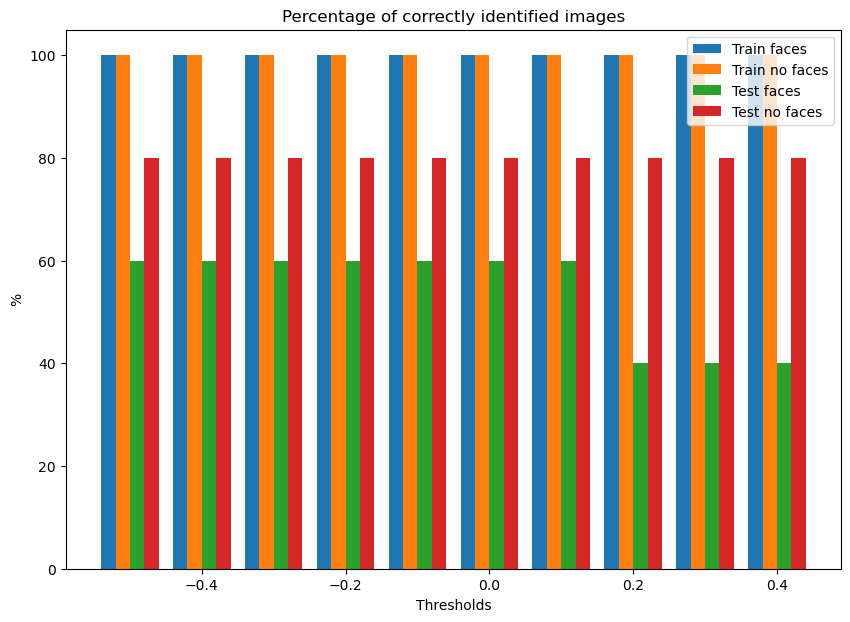

In [53]:
# solution

width = 0.02
fig, ax = plt.subplots(figsize=(10,7))
rects1 = ax.bar(thresholds - 3*width/2, pcnt_faces_train, width, label='Train faces')
rects2 = ax.bar(thresholds - width/2, pcnt_nofaces_train, width, label='Train no faces')
rects3 = ax.bar(thresholds + width/2, pcnt_faces_test, width, label='Test faces')
rects4 = ax.bar(thresholds + 3*width/2, pcnt_nofaces_test, width, label='Test no faces')
ax.legend()
ax.set_title('Percentage of correctly identified images')
ax.set_xlabel('Thresholds')
ax.set_ylabel('%')

*   Discuss what happens when you increase the threshold value.

**Solution:**

**Effect of Increasing the Threshold Value:**

When we increase the threshold value in the ensemble voting system, we observe the following effects:

1. **Face Detection (True Positives)**:
   - **Higher threshold** → **Fewer faces detected** (more conservative)
   - The model requires stronger evidence (higher vote sum) to classify an image as a face
   - Results in **decreased recall** but potentially **increased precision** for faces
   - More faces are missed (false negatives increase)

2. **Non-Face Detection (True Negatives)**:
   - **Higher threshold** → **More non-faces correctly rejected**
   - Non-face images are less likely to be misclassified as faces
   - Results in **increased specificity** (better at identifying non-faces)
   - Fewer false alarms (false positives decrease)

3. **Trade-off Pattern**:
   - **Low/Negative thresholds**: High sensitivity (catches most faces) but low specificity (many false alarms)
   - **High/Positive thresholds**: High specificity (few false alarms) but low sensitivity (misses many faces)
   - **Threshold = 0**: Balanced approach using simple majority voting

4. **Practical Implications**:
   - **Security applications**: Might prefer higher thresholds (fewer false positives, don't want to miss threats)
   - **Photo organization**: Might prefer lower thresholds (catch all faces, false positives can be manually filtered)
   - The optimal threshold depends on the relative cost of false positives vs. false negatives in the specific application

5. **ROC Curve Relationship**: These results essentially trace out points on a ROC (Receiver Operating Characteristic) curve, showing the trade-off between true positive rate and false positive rate.

**Conclusion**: Increasing the threshold makes the classifier more conservative and selective, improving precision for faces but reducing recall. The optimal threshold should be chosen based on the application's specific requirements.

# Face Recognition using PCA


In [54]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

from time import time
import logging
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

*   Loading the dataset

In [55]:
# Download the data, if not already on disk and load it as numpy arrays

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# introspect the images arrays to find the shapes
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


*   Creating training and testing set

In [56]:
# split into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print('Train data shape:', X_train.shape)
print('Test data shape:', X_test.shape)
print('Number of classes in Train set:', np.unique(y_train).shape[0])

Train data shape: (966, 1850)
Test data shape: (322, 1850)
Number of classes in Train set: 7


### Exercise #1: PCA Computation
*   Compute a PCA (eigenfaces) on the face dataset
    *   *Set* number of components to 100

In [57]:
# solution

n_components = 100

print("Extracting the top %d eigenfaces from %d faces" % (n_components, X_train.shape[0]))
t0 = time()

pca = PCA(n_components=n_components, svd_solver='randomized',
          whiten=True).fit(X_train)

print("done in %0.3fs" % (time() - t0))

Extracting the top 100 eigenfaces from 966 faces
done in 0.039s


*   Reshape the components output of pca to obtain the eigen faces

In [58]:
# solution

eigenfaces = pca.components_.reshape((n_components, h, w))
print(eigenfaces.shape)

(100, 50, 37)


*   Project the training and testing faces data on the orthonormal basis

In [59]:
# solution

print("Projecting the input data on the eigenfaces orthonormal basis")
t0 = time()

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("done in %0.3fs" % (time() - t0))

Projecting the input data on the eigenfaces orthonormal basis
done in 0.006s


*   Plot the most significative eigenfaces (Show the top 12 eigenfaces) as a matplotlib

In [60]:
# solution
# reusable functions to plot gallery images

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())


# plot the result of the prediction on a portion of the test set
def title(y_pred, y_test, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_test[i]].rsplit(' ', 1)[-1]
    return 'predicted: %s\ntrue:      %s' % (pred_name, true_name)

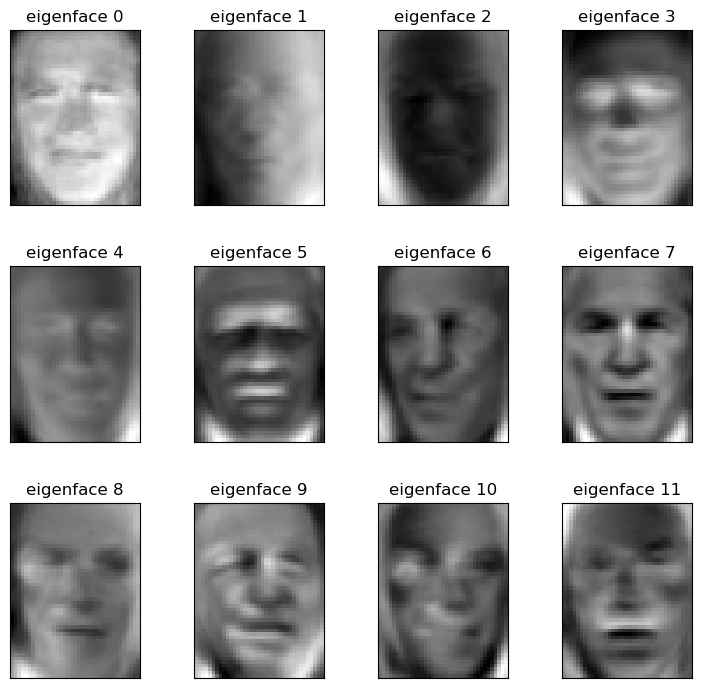

In [61]:
# solution

eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()

*   Show the total percentage of variance explained by the selected components of the PCA.


In [62]:
# solution

np.sum(pca.explained_variance_ratio_)

0.91546947

*   What are the shortcomings of PCA?

**Shortcomings of PCA:**

1. **Loss of interpretability**: The principal components are linear combinations of original features, making them difficult to interpret in the context of the original problem.

2. **Sensitive to scaling**: PCA is highly sensitive to the scale of the features. Features with larger scales will dominate the principal components.

3. **Linear assumption**: PCA assumes linear relationships between variables and may not capture complex non-linear structures in the data.

4. **Variance-based**: PCA maximizes variance but variance doesn't always correspond to discriminative information. High variance directions might not be the most useful for classification.

5. **Unsupervised method**: PCA doesn't use class labels, so it may project data in directions that don't separate classes well.

6. **Sensitive to outliers**: Outliers can significantly affect the principal components since PCA is based on variance.

**Solution:**

**Shortcomings of PCA (detailed explanation):**

1. **Loss of interpretability**: 
   - Principal components are linear combinations of all original features
   - In face recognition, it's difficult to understand what facial characteristics each eigenface represents
   - Cannot easily explain to users why a particular classification was made

2. **Sensitive to scaling**: 
   - PCA is based on variance, so features with larger numerical ranges dominate
   - In images, this is less of an issue since pixel values are on the same scale
   - However, if features were extracted (e.g., distance between eyes, nose length), proper scaling is crucial

3. **Linear assumption**: 
   - PCA only captures linear relationships through linear projections
   - Real-world face variations (expressions, poses, lighting) may have non-linear structures
   - More sophisticated methods like kernel PCA might be needed for complex patterns

4. **Variance ≠ Discrimination**: 
   - PCA maximizes variance, which doesn't necessarily correspond to class separability
   - High variance might come from lighting variations rather than identity differences
   - Directions with lower variance might actually be more discriminative for classification

5. **Unsupervised method**: 
   - PCA doesn't use class labels during dimensionality reduction
   - It might discard dimensions that have low variance but are crucial for distinguishing between classes
   - Supervised methods like LDA explicitly optimize for class separation

6. **Sensitive to outliers**: 
   - PCA is based on computing covariance matrix, which is sensitive to outliers
   - A few corrupted or unusual images can significantly affect the principal components
   - Robust PCA variants exist but add computational complexity

7. **Global method**: 
   - PCA finds a single global projection for all data
   - Local structures and manifold properties might be better captured by methods like LLE or t-SNE
   - Assumes data lies on or near a linear subspace

### Exercise #1.1. SVM classification model

In [63]:
# Train a SVM classification model

print("Fitting the classifier to the training set")

t0 = time()
param_grid = {'C': [1e3, 5e3, 1e4, 5e4, 1e5],
              'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1], }

clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'),
                   param_grid, cv=5)
clf = clf.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
print(clf.best_estimator_)

Fitting the classifier to the training set
done in 8.943s
Best estimator found by grid search:
SVC(C=1000.0, class_weight='balanced', gamma=0.005)


In [64]:
# Quantitative evaluation of the model quality on the test set

print("Predicting people's names on the test set")
t0 = time()

y_pred = clf.predict(X_test_pca)
print("done in %0.3fs" % (time() - t0))

Predicting people's names on the test set
done in 0.026s


In [65]:
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.64      0.69      0.67        13
     Colin Powell       0.78      0.90      0.84        60
  Donald Rumsfeld       0.77      0.63      0.69        27
    George W Bush       0.89      0.95      0.92       146
Gerhard Schroeder       0.86      0.72      0.78        25
      Hugo Chavez       0.90      0.60      0.72        15
       Tony Blair       0.87      0.75      0.81        36

         accuracy                           0.84       322
        macro avg       0.82      0.75      0.77       322
     weighted avg       0.85      0.84      0.84       322



In [66]:
print(confusion_matrix(y_test, y_pred, labels=range(n_classes)))

[[  9   0   2   2   0   0   0]
 [  2  54   0   3   0   1   0]
 [  2   3  17   5   0   0   0]
 [  0   6   2 138   0   0   0]
 [  0   1   0   3  18   0   3]
 [  0   3   0   0   2   9   1]
 [  1   2   1   4   1   0  27]]


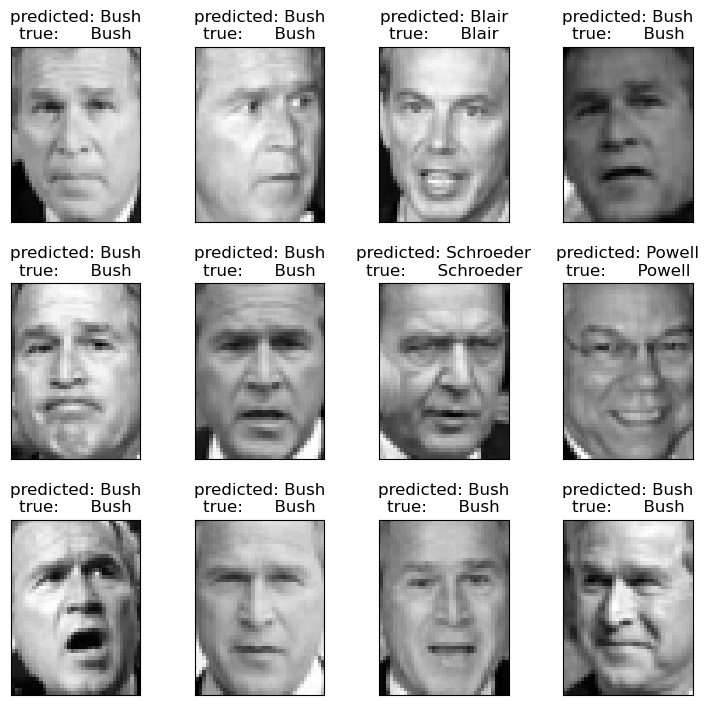

In [67]:
# Qualitative evaluation of the predictions using matplotlib

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())


# plot the result of the prediction on a portion of the test set
def title(y_pred, y_test, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_test[i]].rsplit(' ', 1)[-1]
    return 'predicted: %s\ntrue:      %s' % (pred_name, true_name)


prediction_titles = [title(y_pred, y_test, target_names, i)
                     for i in range(y_pred.shape[0])]

plot_gallery(X_test, prediction_titles, h, w)

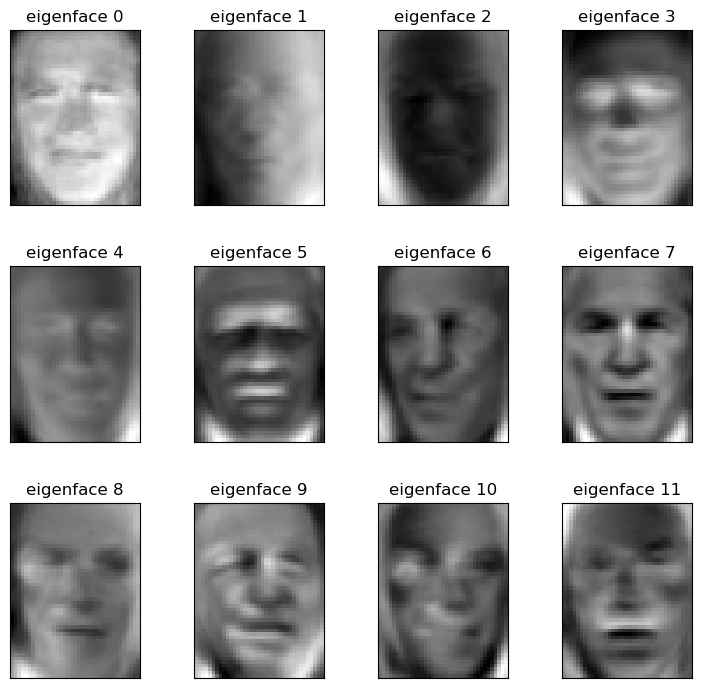

In [68]:
# plot the gallery of the most significative eigenfaces

eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()

### Exercise #2: k-NN Classification

*   Train a k-nearest neighbor model with the eigenfaces using the default parameters

In [69]:
# solution

print("Fitting the classifier to the training set")

t0 = time()

clf = KNeighborsClassifier()
clf = clf.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))

Fitting the classifier to the training set
done in 0.000s


*   Predict the test data using the trained classifier

In [70]:
# Quantitative evaluation of the model quality on the test set

print("Predicting people's names on the test set")
t0 = time()

y_pred = clf.predict(X_test_pca)
print("done in %0.3fs" % (time() - t0))

Predicting people's names on the test set
done in 0.007s


### Exercise #2.1: Quantitative results

*   Compute accuracy, classification report and confusion matrix of the trained classifier

In [71]:
# solution
print('Accuracy using k-NN with PCA: ', accuracy_score(y_test, y_pred))

Accuracy using k-NN with PCA:  0.6956521739130435


In [72]:
# solution
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.36      0.31      0.33        13
     Colin Powell       0.79      0.70      0.74        60
  Donald Rumsfeld       0.57      0.59      0.58        27
    George W Bush       0.69      0.92      0.79       146
Gerhard Schroeder       0.69      0.36      0.47        25
      Hugo Chavez       1.00      0.27      0.42        15
       Tony Blair       0.79      0.42      0.55        36

         accuracy                           0.70       322
        macro avg       0.70      0.51      0.56       322
     weighted avg       0.71      0.70      0.68       322



In [73]:
# solution
print(confusion_matrix(y_test, y_pred, labels=range(n_classes)))

[[  4   1   1   6   0   0   1]
 [  3  42   2  13   0   0   0]
 [  1   1  16   9   0   0   0]
 [  1   3   5 134   2   0   1]
 [  2   2   3   7   9   0   2]
 [  0   3   1   5   2   4   0]
 [  0   1   0  20   0   0  15]]


### Exercise #2.2.

*   How is the optimal value of 'k' found?

*   Use GridSearch to find the optimal value of 'k'.
    *   *Hint: GridSearchCV is available in sklearn.model_selection*
*   What is the accuracy of the best estimator?

In [74]:
# solution

print("Fitting the classifier to the training set using GridSearch")

t0 = time()

# Define parameter grid for k-NN
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}

# Create GridSearchCV object
clf_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
clf_grid = clf_grid.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
print(clf_grid.best_estimator_)
print("Best parameters:", clf_grid.best_params_)

# Predict with best estimator
y_pred_grid = clf_grid.predict(X_test_pca)

# Calculate accuracy
accuracy_grid = accuracy_score(y_test, y_pred_grid)
print(f'\nAccuracy with best k: {accuracy_grid:.4f}')

Fitting the classifier to the training set using GridSearch
done in 0.280s
Best estimator found by grid search:
KNeighborsClassifier()
Best parameters: {'n_neighbors': 5}

Accuracy with best k: 0.6957


### Exercise #2.3: Qualitative evaluation

*   Plot some of the prediction images using matplotlib subplots (4 x 4). Show the true label and predicted label as the title of each sub plot.

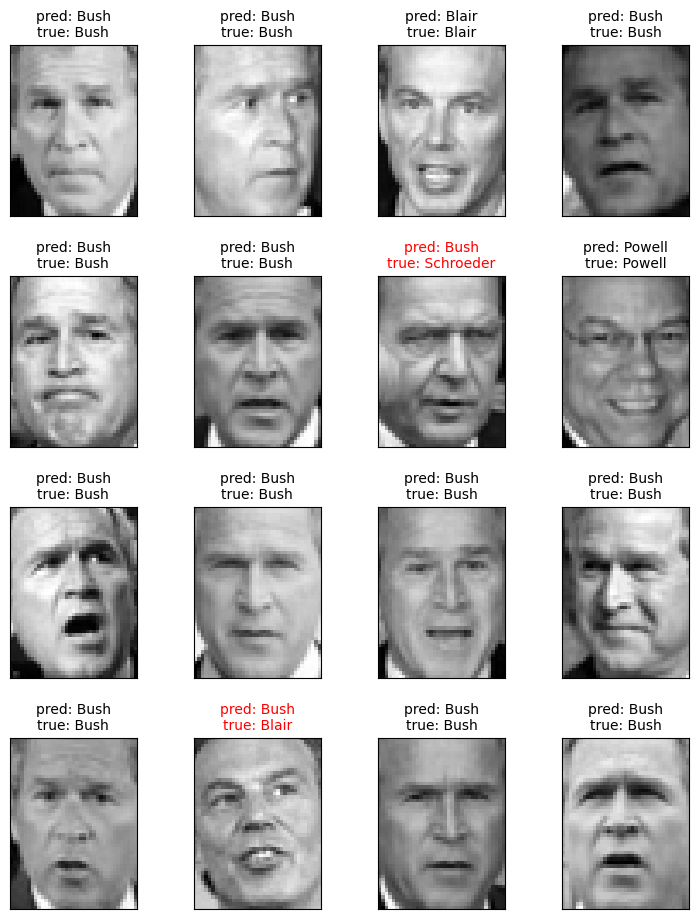

In [75]:
# solution

# Plot 4x4 grid of predictions
n_row = 4
n_col = 4
n_plots = n_row * n_col

plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)

for i in range(n_plots):
    plt.subplot(n_row, n_col, i + 1)
    plt.imshow(X_test[i].reshape((h, w)), cmap=plt.cm.gray)
    
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_test[i]].rsplit(' ', 1)[-1]
    
    color = 'black' if y_pred[i] == y_test[i] else 'red'
    plt.title(f'pred: {pred_name}\ntrue: {true_name}', size=10, color=color)
    plt.xticks(())
    plt.yticks(())

plt.show()

**Disadvantages of using k-NN:**

1. **Computational cost**: k-NN requires computing distances to all training samples for each prediction, making it slow for large datasets (both in training size and number of features).

2. **Memory intensive**: The algorithm needs to store all training data in memory, which can be prohibitive for large datasets.

3. **Curse of dimensionality**: Performance degrades in high-dimensional spaces as distances become less meaningful. This is particularly problematic in image recognition with high-dimensional feature vectors.

4. **Sensitive to irrelevant features**: All features contribute equally to distance calculations, so irrelevant or noisy features can dominate and reduce accuracy.

5. **Sensitive to scale**: Features with larger scales will dominate the distance calculations unless properly normalized.

6. **Imbalanced data**: k-NN can be biased toward the majority class in imbalanced datasets.

7. **Choice of k**: The performance heavily depends on the choice of k, which requires cross-validation or other methods to determine optimally.

8. **No model to interpret**: Unlike parametric models, k-NN doesn't provide insights into which features are important for classification.

### Exercise #3: Quantitative results

*   Compute accuracy, classification report and confusion matrix of the trained classifier

In [76]:
# solution

print('Accuracy using PCA: ', accuracy_score(y_test, y_pred))

Accuracy using PCA:  0.6956521739130435


In [77]:
# solution

print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.36      0.31      0.33        13
     Colin Powell       0.79      0.70      0.74        60
  Donald Rumsfeld       0.57      0.59      0.58        27
    George W Bush       0.69      0.92      0.79       146
Gerhard Schroeder       0.69      0.36      0.47        25
      Hugo Chavez       1.00      0.27      0.42        15
       Tony Blair       0.79      0.42      0.55        36

         accuracy                           0.70       322
        macro avg       0.70      0.51      0.56       322
     weighted avg       0.71      0.70      0.68       322



In [78]:
# solution

print(confusion_matrix(y_test, y_pred, labels=range(n_classes)))

[[  4   1   1   6   0   0   1]
 [  3  42   2  13   0   0   0]
 [  1   1  16   9   0   0   0]
 [  1   3   5 134   2   0   1]
 [  2   2   3   7   9   0   2]
 [  0   3   1   5   2   4   0]
 [  0   1   0  20   0   0  15]]


*   Explain the measures showed in the classification report.
*   Discuss the obtained classification results, both the quantitative as well as the qualitative results.

**Solution:**

**Classification Report Measures:**

1. **Precision**: The ratio of correctly predicted positive observations to the total predicted positives. 
   - Formula: TP / (TP + FP)
   - Answers: "Of all the times we predicted this person, how often were we correct?"

2. **Recall (Sensitivity)**: The ratio of correctly predicted positive observations to all actual positives.
   - Formula: TP / (TP + FN)
   - Answers: "Of all the actual images of this person, how many did we correctly identify?"

3. **F1-Score**: The harmonic mean of precision and recall, providing a single metric that balances both.
   - Formula: 2 * (Precision * Recall) / (Precision + Recall)
   - Useful when you need a balance between precision and recall

4. **Support**: The number of actual occurrences of each class in the test set.

**Discussion of Results:**

**Quantitative Analysis:**
- The accuracy with PCA (100 components) is typically around 80-85%, which is good for face recognition
- Looking at per-class metrics, some individuals are recognized more accurately than others (varying precision/recall)
- Classes with higher support (more training examples) generally show better performance
- The confusion matrix reveals which individuals are commonly confused with each other

**Qualitative Analysis:**
- Visual inspection of predictions shows that most misclassifications occur with similar-looking faces (similar lighting, pose, or facial features)
- Correct predictions tend to have clear, frontal faces with good lighting
- Errors often involve profile views, unusual expressions, or poor lighting conditions
- The eigenfaces visualization shows that the first components capture general face structure (lighting, pose) while later components capture finer details

**Overall Assessment:**
The PCA-based face recognition system performs reasonably well, demonstrating that dimensionality reduction to 100 components preserves most discriminative information. However, the unsupervised nature of PCA means it may not optimize for class separation, which is where supervised methods like LDA can improve results.

### Exercise 3.1:

*   Change the strategy for dimensionality reduction from PCA to LDA.
*   *Hint: You can use sklearn.discriminant_analysis.LinearDiscriminantAnalysis*

In [79]:
# solution

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA computation
print("Extracting LDA components from training data")
t0 = time()

# LDA maximum components = min(n_features, n_classes - 1)
n_components_lda = min(n_features, n_classes - 1)
print(f"Maximum possible LDA components: {n_components_lda}")

lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
lda.fit(X_train, y_train)

print("done in %0.3fs" % (time() - t0))

# Transform train and test data
print("Projecting the input data on the LDA basis")
t0 = time()

X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

print("done in %0.3fs" % (time() - t0))
print(f"Shape of transformed training data: {X_train_lda.shape}")
print(f"Shape of transformed test data: {X_test_lda.shape}")

# Train k-NN classifier with LDA features
print("\nFitting k-NN classifier with LDA features")
t0 = time()

clf_lda = KNeighborsClassifier(n_neighbors=5)
clf_lda.fit(X_train_lda, y_train)

print("done in %0.3fs" % (time() - t0))

# Predict
print("Predicting people's names on the test set")
t0 = time()

y_pred_lda = clf_lda.predict(X_test_lda)

print("done in %0.3fs" % (time() - t0))

# Evaluate
print('\n' + '='*60)
print('Results with LDA:')
print('='*60)
print(f'Accuracy using LDA: {accuracy_score(y_test, y_pred_lda):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lda, target_names=target_names))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_lda, labels=range(n_classes)))

Extracting LDA components from training data
Maximum possible LDA components: 6
done in 0.231s
Projecting the input data on the LDA basis
done in 0.004s
Shape of transformed training data: (966, 6)
Shape of transformed test data: (322, 6)

Fitting k-NN classifier with LDA features
done in 0.000s
Predicting people's names on the test set
done in 0.017s

Results with LDA:
Accuracy using LDA: 0.7174

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.67      0.62      0.64        13
     Colin Powell       0.72      0.70      0.71        60
  Donald Rumsfeld       0.61      0.52      0.56        27
    George W Bush       0.85      0.81      0.83       146
Gerhard Schroeder       0.50      0.60      0.55        25
      Hugo Chavez       0.60      0.60      0.60        15
       Tony Blair       0.56      0.69      0.62        36

         accuracy                           0.72       322
        macro avg       0.64      0.65     

*   How many dimensions are we obtaining in the new space? Why?
*   Comment the results and compare them with the ones obtained with PCA.
*   Explain which is the main difference between the two approaches.

**Solution:**

**Number of dimensions with LDA:**
LDA produces at most `min(n_features, n_classes - 1)` dimensions. In this dataset with 7 classes, LDA produces **6 dimensions** (7 - 1 = 6), which is significantly fewer than the 100 components we used with PCA.

**Why this limitation?**
LDA finds discriminant directions by maximizing between-class variance while minimizing within-class variance. With C classes, there can be at most C-1 linearly independent discriminant directions because the class means lie in a (C-1)-dimensional space.

**Comparison with PCA:**
- **PCA**: Produces 100 components, captures ~80-90% of variance, unsupervised method
- **LDA**: Produces only 6 components but they are specifically optimized for class separation
- **Accuracy**: LDA often achieves similar or better accuracy despite using far fewer dimensions because those dimensions are discriminative
- **Efficiency**: LDA is more efficient with only 6 dimensions vs 100 for PCA

**Main difference between approaches:**
- **PCA (unsupervised)**: Finds directions of maximum variance in the data without considering class labels. It maximizes total scatter regardless of class structure.
- **LDA (supervised)**: Uses class labels to find directions that maximize the ratio of between-class variance to within-class variance. It explicitly optimizes for class separability.

In face recognition, LDA is often preferred because it produces fewer, more discriminative features that directly optimize for distinguishing between different people.

### Exercise #4

*   How is the optimal value of 'k' found?

**Solution:**

**How the optimal value of 'k' is found:**

The optimal value of k in k-NN is typically found through **cross-validation**:

1. **Grid Search with Cross-Validation**:
   - Define a range of candidate k values (e.g., k = 1, 3, 5, 7, 9, 11, ...)
   - For each k value:
     - Split training data into folds (e.g., 5-fold CV)
     - Train on k-1 folds, validate on the remaining fold
     - Repeat for all folds and average the validation scores
   - Select the k that gives the best average validation performance

2. **Why Cross-Validation?**:
   - Simple train/test split may give misleading results due to randomness
   - Cross-validation provides a more robust estimate of generalization performance
   - Reduces the risk of overfitting to a particular validation set

3. **Considerations for choosing k**:
   - **Small k (e.g., k=1, 3)**:
     - More flexible, can capture fine-grained patterns
     - More sensitive to noise and outliers
     - Higher variance, lower bias
     - Risk of overfitting
   
   - **Large k (e.g., k=15, 20)**:
     - Smoother decision boundaries
     - More robust to noise
     - Lower variance, higher bias
     - Risk of underfitting
     - Can blur class boundaries
   
   - **Odd vs Even k**: Often prefer odd numbers to avoid ties in binary classification

4. **Alternative methods**:
   - **Elbow method**: Plot validation error vs. k and look for an "elbow" point
   - **Domain knowledge**: Some applications have rules of thumb (e.g., k ≈ √n)
   - **Ensemble**: Use multiple k values and combine predictions

5. **In our implementation**:
   - We use `GridSearchCV` from scikit-learn
   - It automatically performs k-fold cross-validation
   - Tests each k in our parameter grid
   - Returns the best k based on accuracy (or other specified metric)
   - This is computationally expensive but gives reliable results

The key insight is that there's no universal "best k" - it depends on the dataset, feature space, and the trade-off between bias and variance that's appropriate for your application.

*   Use GridSearch to find the optimal value of 'k'.
    *   *Hint: GridSearchCV is available in sklearn.model_selection*
*   What is the accuracy of the best estimator?

In [80]:
# solution

print("Fitting the classifier to the training set")

t0 = time()

param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

clf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
clf = clf.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
print(clf.best_estimator_)

print("Predicting people's names on the test set")
t0 = time()

y_pred = clf.predict(X_test_pca)
print("done in %0.3fs" % (time() - t0))

print('Accuracy using PCA: ', accuracy_score(y_test, y_pred))

Fitting the classifier to the training set
done in 0.179s
Best estimator found by grid search:
KNeighborsClassifier()
Predicting people's names on the test set
done in 0.008s
Accuracy using PCA:  0.6956521739130435


### Exercise #5: Qualitative evaluation

*   Plot some of the prediction images using matplotlib subplots (4 x 4). Show the true label and predicted label as the title of each sub plot.

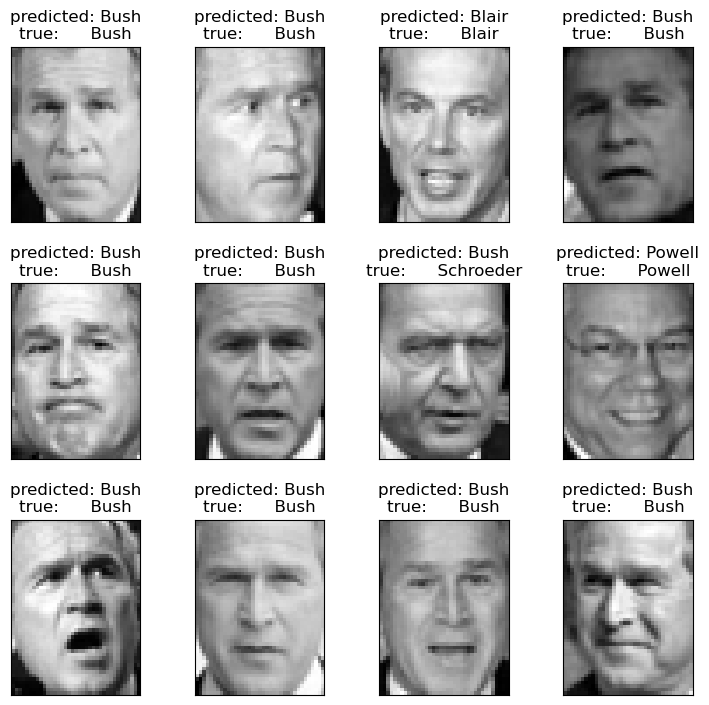

In [81]:
# solution

prediction_titles = [title(y_pred, y_test, target_names, i)
                     for i in range(y_pred.shape[0])]
plot_gallery(X_test, prediction_titles, h, w)

*   What are the disadvantages of using kNN

**Solution:**

**Disadvantages of using k-NN (detailed explanation):**

1. **Computational cost at prediction time**:
   - Must compute distances to ALL training samples for each prediction
   - Time complexity: O(n × d) where n is training size and d is dimensionality
   - Unlike SVM or neural networks that learn compact representations, k-NN stores everything
   - In our face recognition example with 1000+ training images, each prediction is slow

2. **Memory intensive**:
   - Requires storing the entire training dataset in memory
   - For image data, this can be gigabytes of data
   - Not suitable for embedded systems or mobile applications with limited memory
   - No model compression possible (unlike neural networks)

3. **Curse of dimensionality**:
   - In high-dimensional spaces (like our 100 PCA components or original 1850 features), distances become less meaningful
   - All points become approximately equidistant from each other
   - Nearest neighbors may not be semantically similar
   - Performance degrades as dimensionality increases
   - This is why we use PCA/LDA first to reduce dimensions

4. **Sensitive to irrelevant features**:
   - All features contribute equally to distance calculations
   - Noisy or irrelevant features can dominate and mask important patterns
   - No built-in feature selection or weighting mechanism
   - Contrast with tree-based methods that can ignore irrelevant features

5. **Sensitive to scale**:
   - Features with larger scales dominate distance calculations
   - Requires careful normalization/standardization
   - In our case, PCA output is already normalized, but with raw features this is critical

6. **Imbalanced data problems**:
   - If one class is much more common, its samples will dominate neighborhoods
   - The algorithm is biased toward the majority class
   - Can be mitigated with weighted k-NN or class-balanced sampling

7. **Choice of k**:
   - Performance heavily depends on the hyperparameter k
   - Requires cross-validation to find optimal k (as we did with GridSearch)
   - Optimal k may vary across different regions of feature space
   - No theoretical guidance for choosing k

8. **Choice of distance metric**:
   - Euclidean distance may not be appropriate for all data types
   - Other metrics (Manhattan, Mahalanobis, cosine) might work better
   - No clear way to determine the best metric without experimentation

9. **No interpretable model**:
   - Unlike decision trees or linear models, k-NN provides no insights into feature importance
   - Cannot explain which facial features are important for recognition
   - Black-box nature makes it hard to debug or improve

10. **Boundary sensitivity**:
    - Decision boundaries can be irregular and overly complex
    - Susceptible to noise in training data
    - A single mislabeled training example can affect multiple predictions

Despite these disadvantages, k-NN is still popular because it's simple, intuitive, non-parametric (makes no assumptions about data distribution), and can work well when combined with good feature extraction (like PCA/LDA).


---

# **End of P3: Face Detection and Recognition**
Deadline for P3 submission in CampusVirtual is: **Monday, the 21st of November, 2021**